---
numbering: false
---

# 2.7. Matrices

## Introduction

In Chapters 2.4 through 2.6, we focused on understanding the subspace of $\mathbb{R}^n$ **spanned** by a set of vectors. I've been alluding to the fact that to solve the regression problem in higher dimensions, we'd need to be able to **project** a vector onto the span of a set of vectors. (To be clear, we haven't done this yet.) Matrices will allow us to achieve this goal elegantly. It will take a few sections to get there:

- In Chapter 2.7, we'll define matrices, and learn to perform basic operations on them.
- In Chapter 2.8, we'll define the column space, row space, null space, and rank of a matrix, while introducing the CR decomposition along the way.
- In Chapter 2.9, we'll understand matrix-vector multiplication as a transformation of the vector, and learn how to invert a matrix and compute its determinant.
- In Chapter 2.10, we'll learn to project a vector onto the span of the columns of a matrix, closing the loop with Chapter 2.3.

**Just remember that all of this is _for_ machine learning.**

For now, let's consider the following three vectors in $\mathbb{R}^4$:

$$\vec v_1 = \begin{bmatrix} 3 \\ 2 \\ 0 \\ 2 \end{bmatrix}, \quad \vec v_2 = \begin{bmatrix} 1 \\ 1 \\ -1 \\ -2 \end{bmatrix}, \quad \vec v_3 = \begin{bmatrix} 4 \\ 9 \\ 0 \\ 0 \end{bmatrix}$$

If we stack these vectors horizontally, we produce a **matrix**:

$$\begin{bmatrix} \mid & \mid & \mid \\ \vec v_1 & \vec v_2 & \vec v_3 \\ \mid & \mid & \mid \end{bmatrix} = \begin{bmatrix} 3 & 1 & 4 \\ 2 & 1 & 9 \\ 0 & -1 & 0 \\ 2 & -2 & 0 \end{bmatrix}$$


:::{note} Definition: Matrix
A **matrix** is a rectangular array of numbers, organized into rows and columns.

In this class, we'll typically use uppercase letters to denote matrices. For example:

$$A = \begin{bmatrix} 3 & 1 & 4 \\ 2 & 1 & 9 \\ 0 & -1 & 0 \\ 2 & -2 & 0 \end{bmatrix}$$
:::

$A$ is a matrix with 4 rows and 3 columns, so we might say that $A$ is a $4 \times 3$ matrix, or that $A \in \mathbb{R}^{4 \times 3}$.

It's common to use the notation $A_{ij}$ to denote the entry in the $i$-th row and $j$-th column of $A$, e.g. $A_{23} = 9$. 

In `numpy`, you can access the entry in the 2nd row and 3rd column of the 2D matrix `A` using `A[1, 2]`, once we account for the fact that `numpy` uses 0-based indexing.

<iframe
  src="https://jupyterlite.github.io/demo/repl/index.html?kernel=python&code=import numpy as np&code=A = np.array([[3, 1, 4], [2, 1, 9], [0, -1, 0], [2, -2, 0]])&code=A&code=A[1, 2] # Remember that Python uses 0-based indexing!"
  width="100%"
  height="175%"
></iframe>

:::{tip} Activity 1
:class: dropdown

In the cell above, try and find the bottom-right entry of `A`, first using positive indexing and then using negative indexing.
:::

I've introduced matrices in a very particular way, because I'd like for you to think of them as a collection of vectors, sometimes called **column vectors**. We'll come back to this in just a moment. You can also think of a matrix as a collection of row vectors; the example $A$ defined above consists of four row vectors in $\mathbb{R}^3$ stacked horizontally.

When we introduced vectors, $n$ was typically the placeholder we'd use for the number of components of a vector. With matrices, I like using $n$ for the number of rows, and $d$ for the number of columns. This means that, in general, a matrix is of shape $n \times d$ and is a member of the set $\mathbb{R}^{n \times d}$. **This makes clear that when we've collected data, we store each of our $n$ observations in a row of our matrix.** Just be aware that using $n \times d$ to denote the shape of a matrix is a little unorthodox; most other textbooks will use $m \times n$ to denote the shape of a matrix. Of course, this is all arbitrary.

<!-- If $A$ is an arbitrary matrix with $n$ rows and $d$ columns, i.e. $A \in \mathbb{R}^{n \times d}$, we can write $A$ as:

$$A = \begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1d} \\ a_{21} & a_{22} & \cdots & a_{2d} \\ \vdots & \vdots & \ddots & \vdots \\ a_{n1} & a_{n2} & \cdots & a_{nd} \end{bmatrix}$$

We often use the notation $a_{ij}$ to denote the entry in the $i$-th row and $j$-th column of $A$. -->


Suppose $A$ has $n$ rows and $d$ columns, i.e. $A \in \mathbb{R}^{n \times d}$.

- If $n > d$, we say that $A$ is **tall**.
- If $n = d$, we say that $A$ is **square**.
- If $n < d$, we say that $A$ is **wide**.

$$\underbrace{\begin{bmatrix} 5 & 3 \\ 2 & 1 \\ -1 & \frac{1}{3} \\ 3 & 6 \\ 0 & 1 \end{bmatrix}}_{\text{tall}} \qquad \underbrace{\begin{bmatrix} 3 & 0 & 4 \\ 4 & -\pi & 0 \\ \frac{1}{2} & 0 & 1 \end{bmatrix}}_{\text{square}} \qquad \underbrace{\begin{bmatrix} 1 & 0 & 3 & 2 & -1 \\ \frac{1}{9} & 3 & 0 & 0 & 2 \\ 9 & 0 & 0 & 6 & -3 \end{bmatrix}}_{\text{wide}}$$

As we'll see in the coming sections, square matrices are the most flexible – there are several properties and operations that are only defined for them. Unfortunately, not every matrix is square. Remember, matrices are used for storing data, and the number of observations, $n$ and number of features, $d$, don't need to be the same. (In practice, we'll often have very tall matrices, i.e. $n \gg d$, but this is not always the case.)

---

## Addition and Scalar Multiplication

Like vectors, matrices support addition and scalar multiplication out-of-the-box, and both behave as you'd expect.

:::{note} Definition: Addition

Suppose $A$ and $B$ are matrices with the same shape, i.e. $A, B \in \mathbb{R}^{n \times d}$. Then, the **sum** of $A$ and $B$ is the matrix $C$ with entries $C_{ij} = A_{ij} + B_{ij}$ for all $i, j$.

That is, the sum is performed element-wise. The sum is also commutative: $$A + B = B + A$$
:::

:::{note} Definition: Scalar Multiplication

Suppose $A$ is a matrix and $c$ is a scalar. Then, the **scalar multiple** of $A$ by $c$ is the matrix $B$ with entries $B_{ij} = c A_{ij}$ for all $i, j$.

:::

Let's see an example. Consider the matrices $A$ and $B$ (where $A$ is the same as in the previous example):

$$A = \begin{bmatrix} 3 & 1 & 4 \\ 2 & 1 & 9 \\ 0 & -1 & 0 \\ 2 & -2 & 0 \end{bmatrix}, \quad B = \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & 8 & 9 \\ 10 & 11 & 12 \end{bmatrix}$$

Then, the operation $3A - B$ is well-defined, and produces the matrix

$$3A - B = 3 \begin{bmatrix} 3 & 1 & 4 \\ 2 & 1 & 9 \\ 0 & {\color{#3d81f6} \mathbf{-1}} & 0 \\ 2 & -2 & 0 \end{bmatrix} - \begin{bmatrix} 1 & 2 & 3 \\ 4 & 5 & 6 \\ 7 & \color{#3d81f6} \mathbf{8} & 9 \\ 10 & 11 & 12 \end{bmatrix} = \begin{bmatrix} 8 & 1 & 9 \\ 2 & -2 & 21 \\ -7 & \boxed{\color{#3d81f6} \mathbf{-11}} & -9 \\ -4 & -17 & -12 \end{bmatrix}$$

I've colored the entry at position $(3, 2)$ $\color{#3d81f6} \text{blue}$ to help you trace the computation.

$$3 \cdot (-1) - 8 = -11$$

---

## Matrix-Vector Multiplication

Great – we know how to add two matrices, and how to multiply a matrix by a scalar. The natural next step is to figure out how – and why – to multiply two matrices together.

First, a definition.

:::{attention} Golden Rule of Matrix Multiplication
Suppose $A$ and $B$ are two matrices. In order for the product $AB$ to be valid, **the number of columns in $A$ must equal the number of rows in $B$**. 

$$\text{\# columns in } A = \text{\# rows in } B$$

In other words, **the inner dimensions of $A$ and $B$ must match**.
:::

Let's use the Golden Rule. First – as the title of this subsection suggests – we'll start by computing the product of a matrix and a vector.

Let's suppose $A$ is the same $4 \times 3$ matrix we've become familiar with:

$$A = \begin{bmatrix} 3 & 1 & 4 \\ 2 & 1 & 9 \\ 0 & -1 & 0 \\ 2 & -2 & 0 \end{bmatrix}$$

And let's suppose $\vec x$ is some vector. Note that we can think of an $n$-dimensional vector as a matrix with $n$ rows and 1 column. In order for the product $A \vec x$ to be valid, $\vec x$ must have 3 elements in it, by the Golden Rule above. To make the example concrete, let's suppose:

$$\vec x = \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix}$$

How do we multiply $A \vec x$? The following key definition will help us.

:::{note} Definition: Matrix-Vector Multiplication

If $A$ is a $n \times d$ matrix and $\vec x \in \mathbb{R}^d$ is a vector, then the product $A \vec x$ is a vector in $\mathbb{R}^n$ that contains **the dot product of each _row_ of $A$ with $\vec x$**.
:::

<!-- $A$ has 4 rows, and $\vec x$ has 1 column (itself), and so $A \vec x$ will be a vector with 4 components, made up of 4 dot products. -->

Let me say a little more about the dimensions of the output. Below, I've written the dimensions of $A$ ($4 \times 3$) and $\vec x$ ($3 \times 1$) next to each other. By the Golden Rule, the **inner dimensions, both of which are bolded**, must be equal in order for the multiplication to be valid. The dimensions of the output will be the result of looking at the $\boxed{\text{outer dimensions}}$, which here are $4 \times 1$.

$$
\underbrace{A}_{\boxed{4} \times \textbf{3}} \:\:\:\: \underbrace{\vec x}_{\textbf{3} \times \boxed{1}} = \underbrace{\text{output}}_{4 \times 1}
$$

So, the result of multiplying $A \vec x$ will be $4 \times 1$ matrix, or in other words, a vector in $\mathbb{R}^4$. Indeed, the result of multiply a matrix by a vector always results in another vector, and this act of multiplying a matrix by a vector is often thought of as **transforming** the vector from $\mathbb{R}^d$ to $\mathbb{R}^n$.

So, how do we find those 4 components? As mentioned earlier, we compute each component by taking the dot product of a row in $A$ with $\vec x$.

$$A = \begin{bmatrix} \color{#3d81f6} \mathbf{3} & \color{#3d81f6} \mathbf{1} & \color{#3d81f6} \mathbf{4} \\ {\color{orange} \mathbf{2}} & {\color{orange} \mathbf{1}} & {\color{orange} \mathbf{9}} \\ {\color{#d81b60}\mathbf{0}} & {\color{#d81b60} \mathbf{-1}} & {\color{#d81b60} \mathbf{0}} \\ {\color{#004d40} \mathbf{2}} & {\color{#004d40} \mathbf{-2}} & {\color{#004d40} \mathbf{0}} \end{bmatrix}, \quad \vec x = \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix}$$

Let's start with the <span style="color: #3d81f6; font-weight: bold;">top row of</span> $A$, $\color{#3d81f6}\begin{bmatrix} 3 \\ 1 \\ 4\end{bmatrix}$. The dot product of two vectors is only defined if they have equal lengths. **This is why we've instituted the Golden Rule!** The Golden Rule tells us we can only multiply $A$ and $\vec x$ if the number of columns in $A$ is the same as the number of components in $\vec x$, which is true here (both of those numbers are 3).

Then, the dot product of the first row of $A$ with $\vec x$ is:

$${\color{#3d81f6}\begin{bmatrix} \mathbf{3} \\ \mathbf{1} \\ \mathbf{4} \end{bmatrix}} \cdot \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix} = {\color{#3d81f6} \mathbf{3}} \cdot 1 + {\color{#3d81f6} \mathbf{1}} \cdot 0 + {\color{#3d81f6} \mathbf{4}} \cdot 3 = 15$$

Nice! We're a quarter of the way there. Now, we just need to compute the remaining three dot products:

- The dot product of the second row of $A$ with $\vec x$ is ${\color{orange}\begin{bmatrix} \mathbf{2} \\ \mathbf{1} \\ \mathbf{9} \end{bmatrix}} \cdot \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix} = 29$.

- The dot product of the third row of $A$ with $\vec x$ is ${\color{#d81a60}\begin{bmatrix} \mathbf{0} \\ \mathbf{-1} \\ \mathbf{0} \end{bmatrix}} \cdot \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix} = 0$.

- And finally, the dot product of the fourth row of $A$ with $\vec x$ is ${\color{#004d40}\begin{bmatrix} \mathbf{2} \\ \mathbf{-2} \\ \mathbf{0} \end{bmatrix}} \cdot \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix} = 2$.

The result of our matrix-vector multiplication, then, is the result of stacking all 4 dot products together into the vector $\begin{bmatrix} {\color{#3d81f6} \mathbf{15}} \\ {\color{orange} \mathbf{29}} \\ {\color{#d81b60} \mathbf{0}} \\ {\color{#004d40} \mathbf{2}} \end{bmatrix}$. To summarize:

$$\boxed{A \vec x = \begin{bmatrix} {\color{#3d81f6} \mathbf{3}} & {\color{#3d81f6} \mathbf{1}} & {\color{#3d81f6} \mathbf{4}} \\ {\color{orange} \mathbf{2}} & {\color{orange} \mathbf{1}} & {\color{orange} \mathbf{9}} \\ {\color{#d81b60}\mathbf{0}} & {\color{#d81b60} \mathbf{-1}} & {\color{#d81b60} \mathbf{0}} \\ {\color{#004d40} \mathbf{2}} & {\color{#004d40} \mathbf{-2}} & {\color{#004d40} \mathbf{0}} \end{bmatrix} \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix} = \begin{bmatrix} {\color{#3d81f6} \mathbf{15}} \\ {\color{orange} \mathbf{29}} \\ {\color{#d81b60} \mathbf{0}} \\ {\color{#004d40} \mathbf{2}} \end{bmatrix}}$$

**Refer to this example if you're ever confused on how to multiply a matrix by a vector.**

We can't visualize the output vector as it's in 4 dimensions, but we _can_ look at the 4 row vectors of $A$ and the vector $\vec x$ in 3D space.

In [4]:
from utils import plot_vectors

plot_vectors([((3, 1, 4), '#3d81f6', 'row 1'), 
              ((2, 1, 9), 'orange', 'row 2'), 
              ((0, -1, 0), '#d81b60', 'row 3'),
              ((2, -2, 0), '#004d40', 'row 4'),
              ((1, 0, 3), 'purple', 'v')],
              vdeltax=0.8, vdeltay=0.8)

Above, you'll notice that $\color{purple} \vec x = \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix}$ looks the most similar to the **second** row vector, $\color{orange} \begin{bmatrix} \mathbf{2} \\ \mathbf{1} \\ \mathbf{9} \end{bmatrix}$. This explains why in the product $A \vec x = \begin{bmatrix} {\color{#3d81f6} \mathbf{15}} \\ {\color{orange} \mathbf{29}} \\ {\color{#d81b60} \mathbf{0}} \\ {\color{#004d40} \mathbf{2}} \end{bmatrix}$, the largest component ($\color{orange} \mathbf{29}$) is the <span style="color:orange; font-weight: bold">second</span> component. 

$\color{purple} \vec x$ and the third row vector, $\color{#d81b60} \begin{bmatrix} \mathbf{0} \\ \mathbf{-1} \\ \mathbf{0} \end{bmatrix}$, are orthogonal (rotate the plot so that you can see this), so the third component in $A \vec x$ is 0.

:::{tip} Activity 2
:class: dropdown

We'll try not to bore you with mundane calculations in the future, but it's important to perform matrix-vector multiplication by hand a few times to understand how it works. 

In each part, perform the matrix-vector multiplication by hand or state that it cannot be done.

1. $$\begin{bmatrix} 7 & 8 & -1 \\ 0 & 1 & 2 \\ 9 & 0 & \frac{1}{2} \end{bmatrix} \begin{bmatrix} 5 \\ 4 \\ 8 \end{bmatrix}$$
1. $$\begin{bmatrix} 7 & 8 & -1 \\ 0 & 1 & 2 \\ \end{bmatrix} \begin{bmatrix} 5 \\ 4 \end{bmatrix}$$
1. $$\begin{bmatrix} 4 & 2 & 3 \\ 1 & 0 & 1 \\ 5 & 4 & 3 \\ 0 & 0 & 1 \\ \end{bmatrix} \begin{bmatrix} 5 \\ 4 \\ 8 \end{bmatrix}$$
1. $$\begin{bmatrix} 4 & 2 & 3 \\ 1 & 0 & 1 \\ 5 & 4 & 3 \\ 0 & 0 & 1 \\ \end{bmatrix} \begin{bmatrix} 7 & 8 & -1 \\ 0 & 1 & 2 \\ 9 & 0 & \frac{1}{2} \end{bmatrix} \begin{bmatrix} 5 \\ 4 \\ 8 \end{bmatrix}$$
    (While we haven't yet looked at how to compute the product of two matrices, you can still answer this just using what you know about matrix-vector multiplication.)

In the cell below, use `numpy` to verify your answers. You'll need to define the matrices and vectors as `numpy` arrays, and use the `@` operator to perform the matrix-vector multiplication.

<iframe
  src="https://jupyterlite.github.io/demo/repl/index.html?kernel=python&code=import numpy as np&code=A = np.array([[7, 8, -1], [0, 1, 2], [9, 0, 1/2]])&code=B = np.array([[5], [4], [8]])&code=A @ B"
  width="100%"
  height="600px"
></iframe>

:::

---

## The Linear Combination Interpretation

We've described matrix-vector multiplication as the result of taking the dot product of each row of $A$ with $\vec x$, and indeed this is the easiest way to actually compute the output. But, there's another more important interpretation. In the above dot products, you may have noticed:

- Entries in the first column of $A$ ($3$, $2$, $0$, and $2$) were always multiplied by the first element of $\vec x$ ($1$).
- Entries in the second column of $A$ ($1$, $1$, $-1$, and $-2$) were always multiplied by the second element of $\vec x$ ($0$).
- Entries in the third column of $A$ ($4$, $9$, $0$, and $0$) were always multiplied by the third element of $\vec x$ ($3$).

In other words:

$$A \vec x = \begin{bmatrix} 3 & 1 & 4 \\ 2 & 1 & 9 \\ 0 & -1 & 0 \\ 2 & -2 & 0 \end{bmatrix} \begin{bmatrix} \color{orange} \mathbf{1} \\ \color{orange} \mathbf{0} \\ \color{orange} \mathbf{3} \end{bmatrix} = \underbrace{{\color{orange} \mathbf{1}} \begin{bmatrix} 3 \\ 2 \\ 0 \\ 2 \end{bmatrix} + {\color{orange} \mathbf{0}} \begin{bmatrix} 1 \\ 1 \\ -1 \\ -2 \end{bmatrix} + {\color{orange} \mathbf{3}} \begin{bmatrix} 4 \\ 9 \\ 0 \\ 0 \end{bmatrix}}_{\color{orange} \text{linear combination of columns of A}} = \begin{bmatrix} 15 \\ 29 \\ 0 \\ 2 \end{bmatrix}$$

At the start of this section, we defined $A$ by stacking the vectors $\vec u_1$, $\vec u_2$, and $\vec u_3$ side-by-side, and I told you to think of a matrix as a collection of column vectors. The above result is precisely why – it's because when we multiply $A$ by $\vec x$, we're computing a linear combination of the columns of $A$, where the weights are the components of $\vec x$!

Since $A \vec x$ produces a linear combination of the columns of $A$, a natural question to ask at this point is whether the columns of $A$ are all linearly independent. $A$ only has 3 columns, each of which is in $\mathbb{R}^4$, so while they may or may not be linearly independent (are they?), we know they cannot span all of $\mathbb{R}^4$, as we'd need at least 4 vectors to reach every element in $\mathbb{R}^4$.

This is the type of thinking we'll return to in Chapter 2.8. This will lead us to define the **rank** of a matrix, perhaps the single most important number associated with a matrix.

:::{attention} The Two Pictures

Any time you see a matrix-vector product, like $A \vec x$, you should think of it not as a random operation, but as:

1. (**More Important**) A linear combination of the columns of $A$, where the weights are the components of $\vec x$.
$$A \vec x = x_1 \left( \text{column } 1 \text{ of } A \right) + x_2 \left( \text{column } 2 \text{ of } A \right) + \ldots + x_d \left( \text{column } d \text{ of } A \right)$$

2. A dot product of the rows of $A$ with $\vec x$.
$$A \vec x = \begin{bmatrix} (\text{row 1 of } A) \cdot \vec x \\ (\text{row 2 of } A) \cdot \vec x \\ \vdots \\ (\text{row n of } A) \cdot \vec x \end{bmatrix}$$
:::

:::{tip} Activity 3
:class: dropdown

Consider the matrix $M$ defined below.

$$M = \begin{bmatrix} 2 & -1 & 3 & 0 & 4 \\ 1 & 5 & -2 & 1 & 0 \end{bmatrix}$$

In each of the following parts, write out $\vec u$ concretely, compute $M \vec u$, and explain the result in English.

1. A vector whose second component is 1, and whose other components are 0.
2. A vector containing all 1s.
3. A vector containing all $\frac{1}{5}$s.
4. A vector whose components sum to 1, whose first component is $\frac{3}{5}$, and whose other components are all equal to one another.
:::

---

## Matrix Multiplication

Matrix-matrix multiplication – or just "matrix multiplication" – is a generalization of matrix-vector multiplication. Let's present matrix multiplication in its most general terms.

### Definition

:::{note} Definition: Matrix Multiplication
Suppose:
- $A$ is a $n \times d$ matrix.
- $B$ is a $d \times p$ matrix.

Then, $AB$ is a $n \times p$ matrix such that 
- the element in row $i$ and column $j$ of $AB$ is 
- the **dot product of row $i$ of $A$ and column $j$ of $B$**, for $i = 1, 2, ..., n$ and $j = 1, 2, ..., p$.

In other words,

$$(AB)_{ij} = \left( \text{row } i \text{ of } A \right) \cdot \left( \text{column } j \text{ of } B \right) = \sum_{k=1}^d A_{ik} B_{kj}$$
:::

Note that if $p = 1$, this reduces to the matrix-vector multiplication case from before. In that case, the only possible value of $j$ is 1, since the output only has 1 column, and the element in row $i$ of the output vector is the dot product of row $i$ in $A$ and the vector $B$ (which we earlier referred to as $\vec x$ in the less general case).

For a concrete example, suppose $A$ and $B$ are defined below:

$$A = \begin{bmatrix} 3 & 1 & 4 \\ 2 & 1 & 9 \\ 0 & -1 & 0 \\ 2 & -2 & 0 \end{bmatrix} \quad B = \begin{bmatrix} 1 & 2\\ 0 & 7\\ 3 & 2 \end{bmatrix}$$

The number of columns of $A$ must equal the number of rows of $B$ in order for the product $AB$ to be defined, as the Golden Rule tells us. That is fortunately the case here. Since $A$ has shape $\boxed{4} \times 3$ and $B$ has shape $3 \times \boxed{2}$, the output matrix will have shape $4 \times 2$. Each of those $4 \cdot 2 = 8$ elements will be the dot product of a row in $A$ with a column in $B$.

Here is the product of $A$ and $B$:

$$AB = \begin{bmatrix} {\color{#3d81f6} \mathbf{3}} & {\color{#3d81f6} \mathbf{1}} & {\color{#3d81f6} \mathbf{4}} \\ {\color{orange} \mathbf{2}} & {\color{orange} \mathbf{1}} & {\color{orange} \mathbf{9}} \\ {\color{#d81b60}\mathbf{0}} & {\color{#d81b60} \mathbf{-1}} & {\color{#d81b60} \mathbf{0}} \\ {\color{#004d40} \mathbf{2}} & {\color{#004d40} \mathbf{-2}} & {\color{#004d40} \mathbf{0}} \end{bmatrix} \begin{bmatrix} 1 & 2\\ 0 & 7\\ 3 & 2 \end{bmatrix} = \begin{bmatrix} {\color{#3d81f6} \mathbf{15}} & \color{#3d81f6} \mathbf{21} \\ \color{orange} \mathbf{29} & \color{orange} \mathbf{29} \\ \color{#d81b60} \mathbf{0} & \color{#d81b60} \mathbf{-7} \\ \color{#004d40} \mathbf{2} & \color{#004d40} \mathbf{-10} \end{bmatrix}$$

Let's see if we can audit where these numbers came from. Let's consider $(AB)_{32}$, which is the element in row 3 and column 2 of the output. It should have come from the dot product of row 3 of $A$ and column 2 of $B$.

$$AB = \begin{bmatrix} {\color{#3d81f6} \mathbf{3}} & {\color{#3d81f6} \mathbf{1}} & {\color{#3d81f6} \mathbf{4}} \\ {\color{orange} \mathbf{2}} & {\color{orange} \mathbf{1}} & {\color{orange} \mathbf{9}} \\ {\color{#d81b60}\boxed{\mathbf{0}}} & {\color{#d81b60} \boxed{\mathbf{-1}}} & {\color{#d81b60} \boxed{\mathbf{0}}} \\ {\color{#004d40} \mathbf{2}} & {\color{#004d40} \mathbf{-2}} & {\color{#004d40} \mathbf{0}} \end{bmatrix} \begin{bmatrix} 1 & \boxed{2}\\ 0 & \boxed{7}\\ 3 & \boxed{2} \end{bmatrix} = \begin{bmatrix} {\color{#3d81f6} \mathbf{15}} & \color{#3d81f6} \mathbf{21} \\ \color{orange} \mathbf{29} & \color{orange} \mathbf{29} \\ \color{#d81b60} \mathbf{0} & \color{#d81b60} \boxed{\mathbf{-7}} \\ \color{#004d40} \mathbf{2} & \color{#004d40} \mathbf{-10} \end{bmatrix}$$

And indeed, $-7$ is the dot product of $\color{#d81b60}\begin{bmatrix} \mathbf{0} \\ \mathbf{-1} \\ \mathbf{0} \end{bmatrix}$ and $\begin{bmatrix} 2 \\ 7 \\ 2 \end{bmatrix}$.

You should notice that many of the numbers in the output $AB$ look familiar. That's because we used the same $A$ as we did earlier in the section, and the first column of $B$ is just $\vec x$ from the matrix-vector example. So, the first column in $AB$ is the same as the vector $A \vec x = \begin{bmatrix} 15 \\ 29 \\ 0 \\ 2\end{bmatrix}$ as we computed earlier. The difference now is that the output $AB$ isn't just a single vector, but is a matrix with 2 columns. The second column, $\begin{bmatrix} 21 \\ 29 \\ -7 \\ -10\end{bmatrix}$, comes from multiplying $A$ by the second column in $B$, $\begin{bmatrix} 2 \\ 7 \\ 2\end{bmatrix}$.

Note that as we add columns to $B$, we'd add columns to the output. If $B$ had 10 columns, then $AB$ would have 10 columns, too, without $A$ needing to change. As long as the Golden Rule – that the number of columns in $A$ equals the number of rows in $B$ – holds, the product $AB$ can be computed, and it has shape $(\text{number of rows in } A) \times (\text{number of columns in } B)$.

### Properties

:::{note} Properties of Matrix Multiplication

- Matrix multiplication is **associative**. That is, $(AB)C = A(BC)$ for any matrices $A$, $B$, and $C$ that are of the appropriate shapes.
- Matrix multiplication is **distributive**. That is, $A(B + C) = AB + AC$ for any matrices $A$, $B$, and $C$ that are of the appropriate shapes.
- Matrix multiplication is **not commutative**! That is, in general, $AB \neq BA$ for any matrices $A$ and $B$ that are of the appropriate shapes.

:::

The first two properties – associativity and distributivity – match standard arithmetic properties that we've become accustomed to. The associative property allows you to, for example, compute $AB \vec x$ only by using matrix-vector multiplications, since you can first multiply $B \vec x$, which results in a vector, and then multiply $A$ by that vector. (I had you do this in Activity 2 earlier in this section – I hope you did it! 🧐)

The fact that matrix multiplication is **not** commutative may come as a surprise, as every other form of multiplication you've learned about up until this point has been commutative (including the dot product).

:::{warning} **In general, $AB \neq BA$.**
:::

In fact, if $AB$ exists, $BA$ may or may not! If $A$ is $n \times d$ and $B$ is $d \times p$, then $BA$ only exists if $n = p$. But even then, $AB \neq BA$ in general.

For example, if $A$ is $2 \times 3$ and $B$ is $3 \times 2$, then $AB$ is $2 \times 2$ and $BA$ is $3 \times 3$; here, both products exist, but they cannot be equal since they have different shapes.

Even if $A$ and $B$ are both square matrices with the same shape, $AB \neq BA$ in general. For illustration, consider: 

$$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}, \quad B = \begin{bmatrix} 5 & 6 \\ 7 & 8 \end{bmatrix}$$

Then, $$AB = \begin{bmatrix} 19 & 22 \\ 43 & 50 \end{bmatrix} \neq BA = \begin{bmatrix} 23 & 34 \\ 31 & 46 \end{bmatrix}$$

:::{tip} Activity 4
:class: dropdown

**Activity 4.1**

Let $P = \begin{bmatrix} 0 & 0 & 1 \\ 1 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}$, $S = \begin{bmatrix} 4 & 0 & 0 \\ 0 & \frac{1}{2} & 0 \\ 0 & 0 & 3 \end{bmatrix}$, and $\vec x = \begin{bmatrix} 4 \\ 6 \\ 12 \end{bmatrix}$.

1. Evaluate $P \vec x$ and $S \vec x$. Then, explain in words what multiplying $P$ and $S$ by $\vec x$ does to $\vec x$.
1. Evaluate $PS \vec x$ and $SP \vec x$. The results should be different, as we'd expect, since matrix multiplication is not commutative in general. Explain the difference intuitively, given the "operations" $P$ and $S$ perform on $\vec x$.

$P$ is called a permutation matrix, and $S$ is called a diagonal matrix.

**Activity 4.2**

The famous Fibonacci sequence of integers, $F_0, F_1, F_2, \ldots$, is defined as follows:

$$F_0 = 0, \quad F_1 = 1, \quad F_n = F_{n-1} + F_{n-2} \text{ for } n \geq 2$$

The first few terms in the sequence are $0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, \ldots$.

It turns out you can compute the $n$th term in the sequence using matrix multiplication. 

1. Find a $2 \times 2$ matrix $A$ such that $A \begin{bmatrix} F_{n-1} \\ F_{n-2} \end{bmatrix} = \begin{bmatrix} F_n \\ F_{n-1} \end{bmatrix}$. The answer uses relatively small numbers.
1. Compute $A \begin{bmatrix} 1 \\ 0 \end{bmatrix}$, i.e. the product of $A$ and the vector $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$.
1. Since $A$ is square, we can multiply it by itself. Compute $A^2 \begin{bmatrix} 1 \\ 0 \end{bmatrix}$ and $A^3 \begin{bmatrix} 1 \\ 0 \end{bmatrix}$.

If you continue this process, you'll find that $A^n \begin{bmatrix} 1 \\ 0 \end{bmatrix}$ is a vector containing the $n$th and $(n-1)$th terms in the Fibonacci sequence!

**Activity 4.3**

Using the same matrices $P$ and $S$ from Activity 4.1, compute $(P - S) \vec x$ and $P\vec x - S \vec x$. Are both the results the same? If so, what property of matrix multiplication guarantees this?

Is the result of $(P - S) \vec x$ interpretable, in the same way that the results of $P \vec x$ and $S \vec x$ were in Activity 4.1?

:::

### Computation

I've shown you the naïve – and by far most common – algorithm for matrix multiplication. If $A$ and $B$ are both square $n \times n$ matrices, then the runtime of the naïve algorithm is $O(n^3)$.

However, there exist more efficient algorithms for matrix multiplication. Strassen's algorithm is one such example; it describes how to multiply two square $n \times n$ matrices in $O(n^{2.807})$ time. The study of efficient algorithms for matrix multiplication is an active area of research; if you're interested in learning more, look [here](https://en.wikipedia.org/wiki/Computational_complexity_of_matrix_multiplication).

Matrix multiplication, I might argue, is one of the reasons NVIDIA is the most valuable company in the world. Modern machine learning is built on matrix multiplication, and GPUs are optimized for it. Why? This comment [from Reddit](https://www.reddit.com/r/explainlikeimfive/comments/zpso6w/eli5_what_about_gpu_architecture_makes_them/) does a good job of explaining:

> Imagine you have 1 million math assignments to do, they are very simple assignments, but there are a lot that need to be done, they are not dependent on each other so they can be done on any order.
> 
> You have two options, distribute them to 10 thousand people to do it in parallel or give them to 10 math experts. The experts are very fast, but hey, there are only 10 of them, the 10 thousand are more suitable for the task because they have the "brute force" for this.
>
> GPUs have thousands of cores, CPUs have tens.

On that note, the `@` operator in `numpy` is used for matrix multiplication; it is a shorthand for `np.matmul`. You can also use it to multiply a matrix by a vector.

<iframe
  src="https://jupyterlite.github.io/demo/repl/index.html?kernel=python&code=import numpy as np&code=A = np.array([[3, 1, 4], [2, 1, 9], [0, -1, 0], [2, -2, 0]])&code=B = np.array([[1, 2], [0, 7], [3, 2]])&code=A&code=B&code=A @ B # Shorthand for np.matmul(A, B)"
  width="100%"
  height="500px"
></iframe>

:::{warning} The `*` Operator is Not Matrix Multiplication!

The `*` operator in `numpy` is used for element-wise multiplication, not matrix multiplication. If you want to multiply two matrices, you must use the `@` operator.

In the cell above, try and compute the product `A * B` using the `*` operator. What happens?
:::

---

## The Transpose

There's an important operation on matrices that we haven't discussed yet.

### Definition

:::{note} Definition: Transpose

The **transpose** of a matrix $A$ is the matrix $A^T$ with entries $A^T_{ij} = A_{ji}$ for all $i, j$.

Intuitively, the transpose results from replacing the rows of $A$ with the columns of $A$ and vice-versa.
:::

To illustrate, let's start with our familiar matrix $A$:

$$A = \begin{bmatrix} 3 & {\color{#3d81f6} \mathbf{1}} & 4 \\ 2 & {\color{#3d81f6} \mathbf{1}} & 9 \\ 0 & {\color{#3d81f6} \mathbf{-1}} & 0 \\ 2 & {\color{#3d81f6} \mathbf{-2}} & 0 \end{bmatrix}$$

The transpose of $A$ is:

$$A^T = \begin{bmatrix} 3 & 2 & 0 & 2 \\ {\color{#3d81f6} \mathbf{1}} & {\color{#3d81f6} \mathbf{1}} & {\color{#3d81f6} \mathbf{-1}} & {\color{#3d81f6} \mathbf{-2}} \\ 4 & 9 & 0 & 0 \end{bmatrix}$$

Note that $A \in \mathbb{R}^{4 \times 3}$ and $A^T \in \mathbb{R}^{3 \times 4}$.

Why would we ever need to do this? To illustrate, suppose $\vec u = \begin{bmatrix} u_1 \\ u_2 \\ u_3 \\ u_4 \end{bmatrix}$, and that we'd like to compute the product $A^T \vec u$. (Note that $\vec u$ must be in $\mathbb{R}^4$ in order for $A^T \vec u$ to be defined, unlike $\vec x \in \mathbb{R}^3$ in the product $A \vec x$). Then:

$$\begin{align*}A^T \vec u &= \begin{bmatrix} 3 & 2 & 0 & 2 \\ 1 & 1 & -1 & -2 \\ 4 & 9 & 0 & 0 \end{bmatrix} \begin{bmatrix} {\color{orange} \mathbf{u_1}} \\ {\color{orange} \mathbf{u_2}} \\ {\color{orange} \mathbf{u_3}} \\ {\color{orange} \mathbf{u_4}} \end{bmatrix} \\ &= {\color{orange} \mathbf{u_1}} \begin{bmatrix} 3 \\ 1 \\ 4 \end{bmatrix} + {\color{orange} \mathbf{u_2}} \begin{bmatrix} 2 \\ 1 \\ 9 \end{bmatrix} + {\color{orange} \mathbf{u_3}} \begin{bmatrix} 0 \\ -1 \\ 0 \end{bmatrix} + {\color{orange} \mathbf{u_4}} \begin{bmatrix} 2 \\ -2 \\ 0 \end{bmatrix} \end{align*}$$

This is a linear combination of the **rows** of $A$, where the weights are the components of $\vec u$. Remember, the standard product $A \vec x$ is a linear combination of the columns of $A$, so the transpose helps us if we want to compute a linear combination of the rows of $A$. (Equivalently, it helps us if we want to compute the dot product of the **columns of $A$** with $\vec u$ – see the "Two Pictures" note from earlier in this chapter.)

The transpose also gives us another way of expressing the dot product of two vectors. If $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ are two vectors in $\mathbb{R}^n$, then $\color{orange} \vec u^T$ is a row vector with 1 row and $n$ columns. Multiplying $\color{orange} \vec u^T$ by $\color{#3d81f6} \vec v$ results in a $1 \times 1$ matrix, which is just the scalar ${\color{orange} \vec u} \cdot {\color{#3d81f6} \vec v}$.

$$
\vec {\color{orange}u}^T \vec{\color{#3d81f6}v} = \begin{bmatrix} {\color{orange}u_1} & {\color{orange}u_2} & \ldots & {\color{orange}u_n} \end{bmatrix} \begin{bmatrix}{\color{#3d81f6}v_1} \\{\color{#3d81f6}v_2} \\ \vdots \\{\color{#3d81f6}v_n} \end{bmatrix} = {\color{orange}u_1}{\color{#3d81f6}v_1} + {\color{orange}u_2}{\color{#3d81f6}v_2} + \ldots + {\color{orange}u_n}{\color{#3d81f6}v_n} = \vec {\color{orange}u} \cdot \vec{\color{#3d81f6}v} = \vec{\color{#3d81f6}v} \cdot \vec {\color{orange}u} = \vec{\color{#3d81f6}v}^T \vec {\color{orange}u}
$$

:::{warning} Transpose, or Dot, but Not Both!

The following are all valid ways of computing the dot product of $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$, assuming they have the same number of components:

$$
{\color{orange} \vec u} \cdot {\color{#3d81f6} \vec v} = {\color{orange} \vec u^T} {\color{#3d81f6} \vec v} = {\color{#3d81f6} \vec v^T} {\color{orange} \vec u} = {\color{#3d81f6} \vec v} \cdot {\color{orange} \vec u}
$$

However, ${\color{orange} \vec u^T} \cdot {\color{#3d81f6} \vec v}$ **is not defined**. The dot product is only defined for two vectors of the same dimensions, but $\color{orange} \vec u^T$ is a row vector with $n$ columns, and $\color{#3d81f6} \vec v$ is a column vector with $n$ rows.

:::

The benefit of using the transpose to express the dot product is that it allows us to write the dot product of two vectors in terms of matrix multiplication, rather than being an entirely different type of operation. (In fact, as we've seen here, matrix multiplication is just a generalization of the dot product.)

There are other uses for the transpose, too, so it's a useful tool to have in your toolbox.

### Properties

:::{note} Properties of the Transpose
- $(A^T)^T = A$, i.e. the transpose of the transpose of a matrix is the original matrix.
- $(A + B)^T = A^T + B^T$.
- $(cA)^T = cA^T$ for any scalar $c \in \mathbb{R}$.
- $(AB)^T = B^T A^T$.
:::

The first three properties are relatively straightforward. The last property is a bit more subtle. Try and reason as to why it's true on your own, then peek into the box below to verify your reasoning and to see an example.

:::{admonition} Why is $(AB)^T = B^T A^T$?
:class: dropdown

Let's start with just $(AB)^T$ and reason our way from there. Define $C = (AB)^T$. $C$ is presumably the product of two matrices $X$ and $Y$, we just don't know what $X$ and $Y$ are. By the definition of matrix multiplication, we know that $C_{ij}$ is the dot product of the $i$th row of $X$ and the $j$th column of $Y$. How can we express the product $C = XY$ in terms of $A$ and $B$?

Let's work backwards. Since $C_{ij} = (AB)^T_{ij} = (AB)_{ji}$ by the definition of the transpose, we know that: 

$$C_{ij} = (AB)_{ji} = \left( \text{row } j \text{ of } A \right) \cdot \left( \text{column } i \text{ of } B \right) = \left( \text{column } i \text{ of } B \right) \cdot \left( \text{row } j \text{ of } A \right)$$

This is a little backwards relative to the definition of matrix multiplication, which says that:

$$C_{ij} = (XY)_{ij} = \left( \text{row } i \text{ of } X \right) \cdot \left( \text{column } j \text{ of } Y \right)$$

In order for the two definitions of $C_{ij}$ to be consistent, we must have:

$$\left( \text{column } i \text{ of } B \right) \cdot \left( \text{row } j \text{ of } A \right) = \left( \text{row } i \text{ of } X \right) \cdot \left( \text{column } j \text{ of } Y \right)$$

- Row $i$ of $X$ is the same as column $i$ of $B$, if $X = B^T$.
- Column $j$ of $Y$ is the same as row $j$ of $A$, if $Y = A^T$.

Putting this together, we have:

$$C = (AB)^T = B^T A^T$$

as we hoped!

To make things concrete, let's consider two new matrices $A$ and $B$:

$$A = \begin{bmatrix} 0 & -1 \\ 4 & 2 \\ 3 & 9 \\ 0 & 1 \end{bmatrix} \quad B = \begin{bmatrix} 1 & 2 & 3 \\ -1 & -2 & 4 \end{bmatrix}$$

Then,

$$AB = \begin{bmatrix} 0 & -1 \\ 4 & 2 \\ {\color{#3d81f6} \mathbf{3}} & {\color{#3d81f6} \mathbf{9}} \\ 0 & 1 \end{bmatrix} \begin{bmatrix} 1 & 2 & {\color{#3d81f6} \mathbf{3}} \\ -1 & -2 & {\color{#3d81f6} \mathbf{4}} \end{bmatrix} = \begin{bmatrix} 1 & 2 & -4 \\ 2 & 4 & 20 \\ -6 & -12 & \boxed{{\color{#3d81f6} \mathbf{45}}} \\ -1 & -2 & 4 \end{bmatrix}$$

And:

$$B^T A^T = \begin{bmatrix} 1 & -1 \\ 2 & -2 \\ {\color{#3d81f6} \mathbf{3}} & {\color{#3d81f6} \mathbf{4}} \end{bmatrix} \begin{bmatrix} 0 & 4 & {\color{#3d81f6} \mathbf{3}} & 0 \\ -1 & 2 & {\color{#3d81f6} \mathbf{9}} & 1 \end{bmatrix} = \begin{bmatrix} 1 & 2 & -6 & -1 \\ 2 & 4 & -12 & -2 \\ -4 & 20 & \boxed{{\color{#3d81f6} \mathbf{45}}} & 4 \end{bmatrix}$$

$B^T A^T$ is the transpose of $AB$. Both $AB$ and $B^T A^T$ have 12 elements, both computed using the same 12 dot products.

:::

The fact that $(AB)^T = B^T A^T$ comes in handy when finding the norm of a matrix-vector product. If $A$ is an $n \times d$ matrix and $\vec x \in \mathbb{R}^d$, then:

$$\lVert A \vec x \rVert^2 = (A \vec x)^T (A \vec x) = \vec x^T A^T A \vec x$$

As we'll soon see, some matrices $A$ have special properties that make this computation particularly easy.

In `numpy`, the `T` attribute is used to compute the transpose of a 2D array.

<iframe
  src="https://jupyterlite.github.io/demo/repl/index.html?kernel=python&code=import numpy as np&code=A = np.array([[3, 1, 4], [2, 1, 9], [0, -1, 0], [2, -2, 0]])&code=A&code=A.T"
  width="100%"
  height="175%"
></iframe>

:::{tip} Activity 6
:class: dropdown

**Activity 6.1**

In the cell above:

1. Define `x` to be an array corresponding to the vector $\vec x = \begin{bmatrix} 1 \\ 0 \\ 3 \end{bmatrix}$.
2. Find the norm of the product $A \vec x$ using `np.linalg.norm`.
3. Find the norm of the product $A \vec x$ using the fact that $\lVert A \vec x \rVert^2 = \vec x^T A^T A \vec x$, and verify that you get the same answer.

**Activity 6.2**

Suppose $M \in \mathbb{R}^{n \times d}$ is a matrix, $\vec{v} \in \mathbb{R}^d$ is a vector, and $s \in \mathbb{R}$ is a scalar.

Determine whether each of the following quantities is a matrix, vector, scalar, or undefined. If the result is a matrix or vector, determine its dimensions.

1. $M\vec{v}$

2. $\vec{v} M$

3. $\vec{v}^2$

4. $M^TM$

5. $MM^T$

6. $\vec{v}^T M \vec{v}$

7. $(sM\vec{v}) \cdot (sM\vec{v})$

8. $(s \vec{v}^T M^T)^T$

9. $\vec{v}^T M^T M \vec{v}$

10. $\vec{v}\vec{v}^T + M^TM$

11. $\frac{M \vec{v}}{\lVert \vec{v} \rVert} + (\vec{v}^T M^T M \vec{v}) M \vec{v}$

**Activity 6.3**

Let $A = \begin{bmatrix} 2 & 1 \\ 3 & 4 \\ -1 & 1 \end{bmatrix}$, $B = \begin{bmatrix} 1 & 0 & 2 \\ 2 & 1 & 3 \end{bmatrix}$, and $C = \begin{bmatrix} 1 & 0 & 2 & -1 \\ 0 & 1 & 1 & 1 \\ 1 & 1 & 0 & -1 \end{bmatrix}$.

1. Compute $AB$, then multiply the result by $C$.
1. Compute $A$, then multiply the result by $BC$. Do you get the same result as above? If so, what property of matrix multiplication guarantees this?
1. Determine a formula for $(ABC)^T$, and verify that your result works. (Hint: Start with the fact that $(AB)^T = B^T A^T$.)
:::

---

## The Identity Matrix

:::{admonition} Definition: Identity Matrix

The **identity matrix** is the square matrix $I$ with ones on the diagonal and zeros everywhere else.

$$I = \begin{bmatrix} 1 & 0 & \ldots & 0 \\ 0 & 1 & \ldots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \ldots & 1 \end{bmatrix}$$

:::

Saying "the identity matrix" is a bit ambiguous, as there are infinitely many identity matrices – there's a $1 \times 1$ identity matrix, a $2 \times 2$ identity matrix, a $3 \times 3$ identity matrix, and so on. Often, the dimension of the identity matrix is implied by context, and if not, we might provide it as a subscript, e.g. $I_n$ for the $n \times n$ identity matrix.

Why is the identity matrix defined this way? It's the matrix equivalent of the number $1$ in scalar multiplication, also known as the multiplicative identity. If $c$ is a scalar, then $c \cdot 1 = c$ and $1 \cdot c = c$. (0 is known as the additive identity in scalar multiplication.)

Similarly, if $A$ is **square** $n \times n$ matrix and $\vec x \in \mathbb{R}^n$ is a vector, then the $n \times n$ identity matrix $I$ is the unique matrix that satisfies:
- $I \vec x = \vec x$ for all $\vec x \in \mathbb{R}^n$.
- $I A = A I = A$ for all $A \in \mathbb{R}^{n \times n}$.

A good exercise is to verify that the identity matrix satisfies these properties.

:::{tip} Activity 7
:class: dropdown

Let $X = \begin{bmatrix} 1 & -2 \\ -1 & 3 \\ 2 & 0 \\ 0 & -1 \\ 3 & 2 \end{bmatrix}$.

1. Compute $X^TX$. 
2. Then, compute the transpose of $X^TX$. What do you notice? ($X^TX$ is called a _symmetric_ matrix.)
3. Compute $X^TX + \frac{1}{2} I$. We'll use matrices of the form $X^TX + \lambda I$ in Chapter 5.
:::

---

## Preview: Transformations

This section was relatively mechanical, and I didn't spend much time explaining _why_ we'd multiply two matrices (or a matrix and a vector) together. More context for this operation will come throughout the rest of the chapter.

To conclude, I want to show you _some_ of the magic behind matrix multiplication.

Consider the relatively innocent looking $2 \times 2$ matrix

$$A = \begin{bmatrix} \frac{\sqrt{3}}{2} & -\frac{1}{2} \\[6pt] \frac{1}{2} & \frac{\sqrt{3}}{2} \end{bmatrix}$$

Below, you'll see that I've drawn out six vectors in $\mathbb{R}^2$.

- $\color{orange} \vec u = \begin{bmatrix} 3 \\ 2 \end{bmatrix}$ and $A \color{orange} \vec u$
- $\color{#3d81f6} \vec v = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$ and $A \color{#3d81f6} \vec v$
- $\color{#d81a60} \vec w = \begin{bmatrix} -5 \\ -4 \end{bmatrix}$ and $A \color{#d81a60} \vec w$

What do you notice about the vectors $A \color{orange} \vec u$, $A \color{#3d81f6} \vec v$, and $A \color{#d81a60} \vec w$? and how they relate to $\color{orange} \vec u$, $\color{#3d81f6} \vec v$, and $\color{#d81a60} \vec w$?

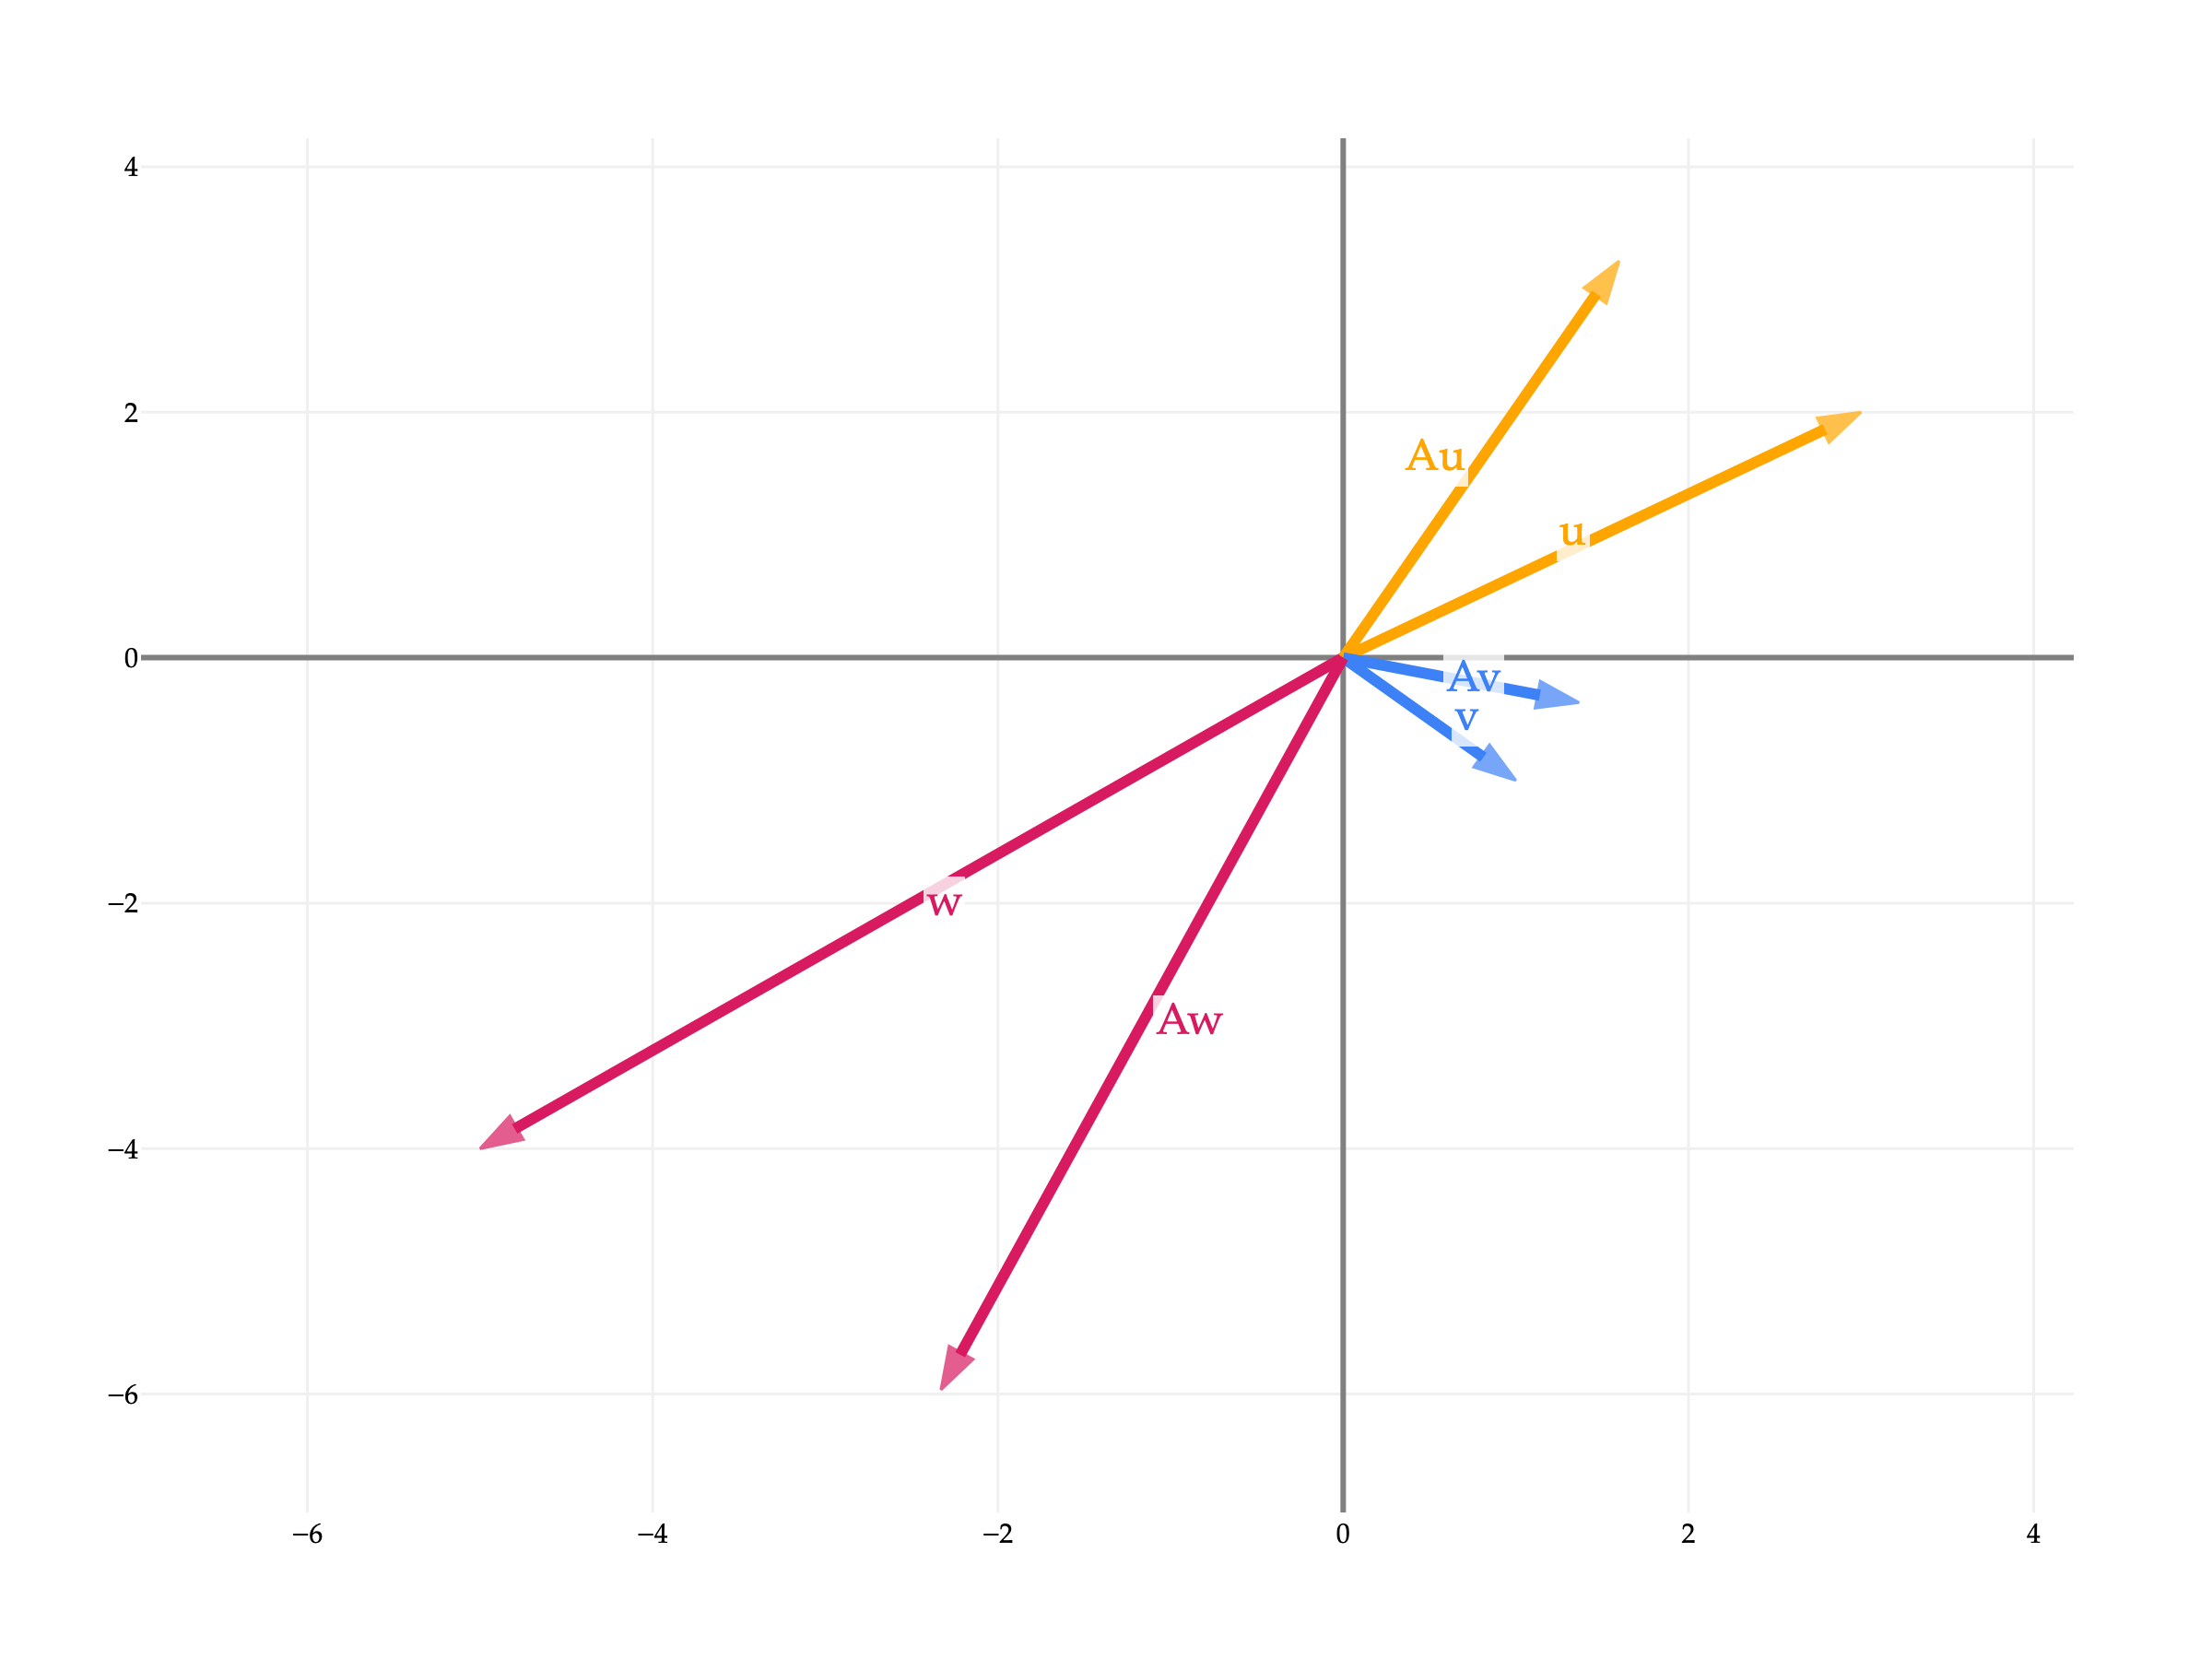

In [1]:
from utils import plot_vectors
import numpy as np

A = np.array([[np.cos(np.pi/6), -np.sin(np.pi/6)], [np.sin(np.pi/6), np.cos(np.pi/6)]])
u = np.array([3, 2])
v = np.array([1, -1])
w = np.array([-5, -4])

Au = A @ u
Av = A @ v
Aw = A @ w

fig = plot_vectors([(tuple(u), 'orange', 'u'),
              (tuple(v), '#3d81f6', 'v'),
              (tuple(w), '#d81a60', 'w'),
              (tuple(Au), 'orange', 'Au'),
              (tuple(Av), '#3d81f6', 'Av'),
              (tuple(Aw), '#d81a60', 'Aw')], vdeltay=0)

fig.show(scale=3, renderer='png')

$A$ is called a **rotation matrix**, since it rotates vectors by a certain angle (in this case, $\frac{\pi}{6}$ radians, or $30^\circ$). Rotations are a type of **linear transformation**.

Not all matrices are rotation matrices; there exist plenty of different types of linear transformations, like reflections, sheers, and projections (which sound familiar). These will all become familiar in Chapter 2.9. All I wanted to show you for now is that matrix multiplication may _look_ like a bunch of random number crunching, but there's a lot of meaning baked in.